   order_id  restaurant_id  order_confirm_time   merchant_mark_ready_time  \
0         1            103 2025-01-12 20:35:00 2025-01-12 20:58:26.500385   
1         2            436 2025-01-11 16:31:00 2025-01-11 16:50:54.784767   
2         3            349 2025-01-16 15:11:00 2025-01-16 15:27:00.000000   
3         4            271 2025-01-29 06:51:00 2025-01-29 06:59:36.992901   
4         5            107 2025-01-28 19:12:00 2025-01-28 19:51:08.382929   

   rider_arrival_time                pickup_time              delivery_time  \
0 2025-01-12 20:51:00 2025-01-12 21:00:26.500385 2025-01-12 21:12:26.500385   
1 2025-01-11 16:54:00 2025-01-11 16:50:54.784767 2025-01-11 17:07:54.784767   
2 2025-01-16 15:27:00 2025-01-16 15:29:47.423662 2025-01-16 15:49:47.423662   
3 2025-01-29 07:12:00 2025-01-29 07:01:36.992901 2025-01-29 07:16:36.992901   
4 2025-01-28 19:28:00 2025-01-28 19:51:08.382929 2025-01-28 20:05:08.382929   

   is_peak_hour  rider_wait_time  kpt_baseline  ...  for_bias_

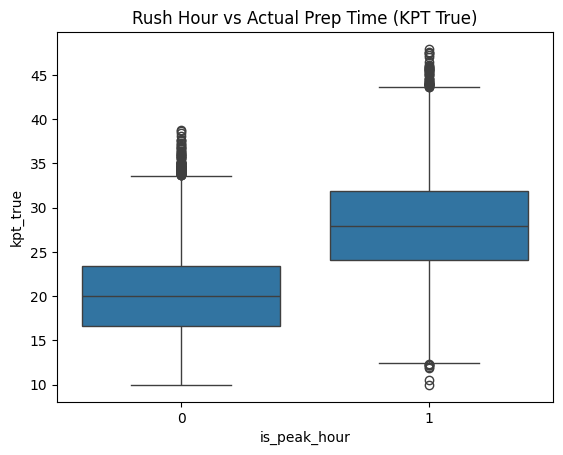

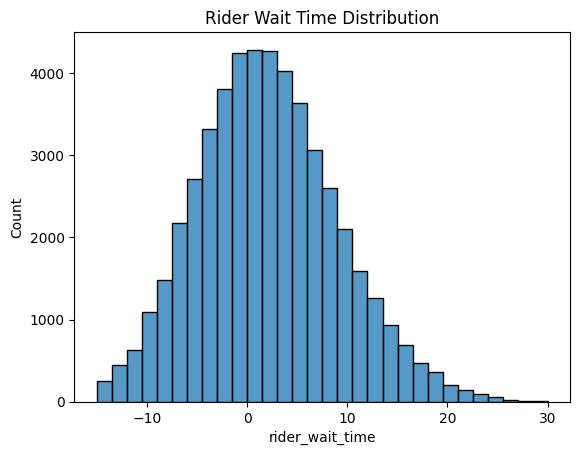

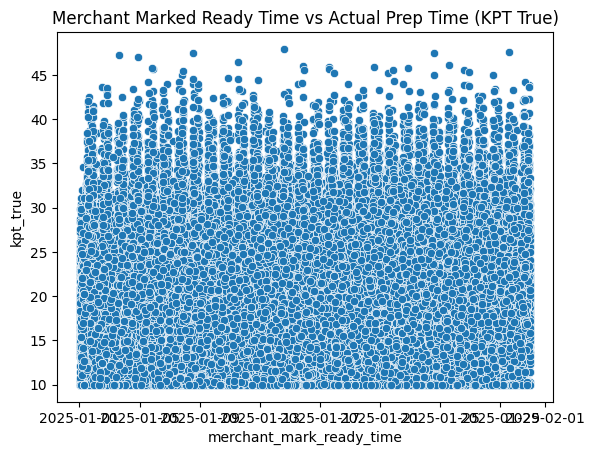

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/kpt_synthetic_dataset.csv")

# Convert timestamp columns to datetime objects
timestamp_cols = [
    "order_confirm_time",
    "merchant_mark_ready_time",
    "rider_arrival_time",
    "pickup_time",
    "delivery_time"
]
for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col])

print(df.head())
print(df.describe())

# The original line for rider_wait_time had a KeyError and a type mismatch issue.
# The dataset already contains a 'rider_wait_time' column, which will be used for plotting.
# If a new rider wait time calculation is desired, it should be defined based on
# available timestamp columns, e.g., (df['pickup_time'] - df['rider_arrival_time']).dt.total_seconds() / 60

# Plot 1: Rush Hour Effect
plt.figure()
sns.boxplot(x="is_peak_hour", y="kpt_true", data=df) # Changed 'rush_hour' to 'is_peak_hour'
plt.title("Rush Hour vs Actual Prep Time (KPT True)")
plt.savefig("rush_hour_effect.png")
plt.show()

# Plot 2: Rider Wait Time Distribution
plt.figure()
sns.histplot(df["rider_wait_time"], bins=30) # Using existing 'rider_wait_time' column
plt.title("Rider Wait Time Distribution")
plt.savefig("rider_wait_distribution.png")
plt.show()

# Plot 3: Merchant Bias
plt.figure()
sns.scatterplot(x="merchant_mark_ready_time", # Corrected column name and ensures it's datetime
                y="kpt_true",                # Changed 'actual_prep_time' to 'kpt_true'
                data=df)
plt.title("Merchant Marked Ready Time vs Actual Prep Time (KPT True)")
plt.savefig("merchant_bias.png")
plt.show()